In [40]:
import random
import matplotlib.pyplot as plt

The Genetic Algorithm uses:
| Parameter             | Value |
| --------------------- | ----- |
| Population Size       | 10    |
| Chromosome Length     | 5     |
| Crossover Probability | 0.8   |
| Mutation Probability  | 0.01  |
| Generations           | 50    |


In [41]:
POP_SIZE = 10
CHROM_LENGTH = 5
PC = 0.8
PM = 0.01
GENERATIONS = 50

In [42]:
def generate_population(size, length):
    population = []

    for _ in range(size):
        chromosome = ''.join(
            random.choice('01')
            for _ in range(length)
        )
        population.append(chromosome)

    return population

In [43]:
def decode(chromosome):
    return int(chromosome, 2)

In [44]:
def fitness(chromosome):
    x = decode(chromosome)
    return x ** 2

In [45]:
def roulette_selection(population):

    fitness_values = [fitness(ch) for ch in population]

    total_fitness = sum(fitness_values)

    probabilities = [
        fit / total_fitness
        for fit in fitness_values
    ]

    selected = random.choices(
        population,
        weights=probabilities,
        k=len(population)
    )

    return selected

In [46]:
def crossover(parent1, parent2):

    if random.random() < PC:

        point = random.randint(
            1,
            CHROM_LENGTH - 1
        )

        child1 = (
            parent1[:point] +
            parent2[point:]
        )

        child2 = (
            parent2[:point] +
            parent1[point:]
        )

        return child1, child2

    return parent1, parent2

In [47]:
def mutate(chromosome):

    chromosome = list(chromosome)

    for i in range(len(chromosome)):

        if random.random() < PM:

            chromosome[i] = (
                '1'
                if chromosome[i] == '0'
                else '0'
            )

    return ''.join(chromosome)

In [48]:
def get_best(population):

    return max(
        population,
        key=fitness
    )

In [49]:
population = generate_population(
    POP_SIZE,
    CHROM_LENGTH
)

best_history = []
avg_history = []

for generation in range(GENERATIONS):

    fitness_values = [
        fitness(ch)
        for ch in population
    ]

    best_fit = max(fitness_values)

    avg_fit = (
        sum(fitness_values)
        / len(fitness_values)
    )

    best_history.append(best_fit)
    avg_history.append(avg_fit)

    elite = get_best(population)

    selected = roulette_selection(population)

    next_population = []

    while len(next_population) < POP_SIZE - 1:

        p1 = random.choice(selected)
        p2 = random.choice(selected)

        c1, c2 = crossover(p1, p2)

        c1 = mutate(c1)
        c2 = mutate(c2)

        next_population.append(c1)

        if len(next_population) < POP_SIZE - 1:
            next_population.append(c2)

    next_population.append(elite)

    population = next_population

In [50]:
best_chromosome = get_best(population)

best_x = decode(best_chromosome)

best_fitness = fitness(best_chromosome)

print("\nFinal Results")
print("-" * 40)

print("Best Chromosome :", best_chromosome)
print("Decoded Value   :", best_x)
print("Best Fitness    :", best_fitness)

print("\nFinal Population")

for ch in population:
    print(ch)


Final Results
----------------------------------------
Best Chromosome : 11111
Decoded Value   : 31
Best Fitness    : 961

Final Population
10111
11111
10111
10111
10111
11111
11111
11111
11111
11111


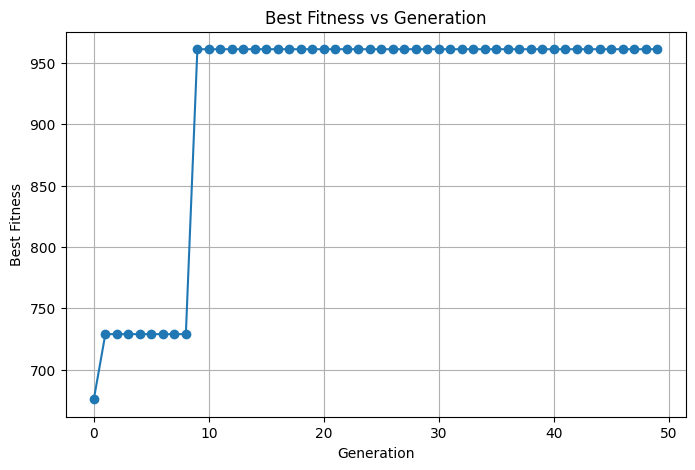

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    best_history,
    marker='o'
)

plt.title(
    "Best Fitness vs Generation"
)

plt.xlabel("Generation")
plt.ylabel("Best Fitness")

plt.grid(True)

plt.show()

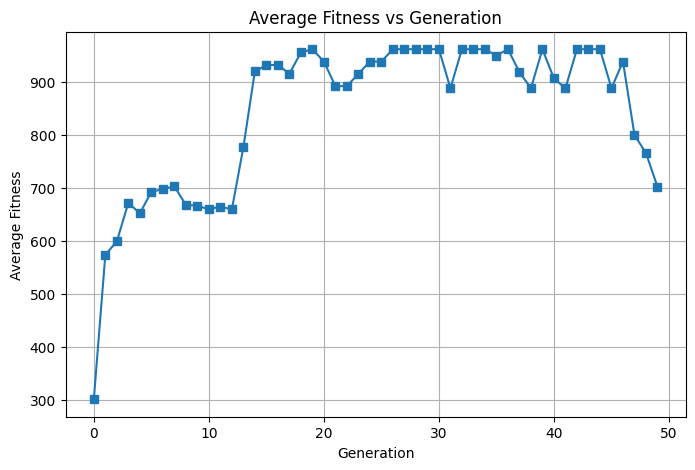

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    avg_history,
    marker='s'
)

plt.title(
    "Average Fitness vs Generation"
)

plt.xlabel("Generation")
plt.ylabel("Average Fitness")

plt.grid(True)

plt.show()